# H251 Data Exploration - AIF360

raw data instead of dataset from lib
* H251 --> most recent dataset (2023) 
* H243 --> second most recent dataset (2022)

https://github.com/Trusted-AI/AIF360

In [85]:
"""
    in case we use aif360 MEPSdataset19 -> do pip installs
    i didn't use it because the data was older
    i chose the most recent data which i had to download raw xlxs file
    and then convert to csv
        - h252
        - h243 -> i didnt use it, but we could, it has same structure
"""
# %pip install 'aif360[all]'
# %pip install fairlearn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# General Imports

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [87]:
data_h251 = pd.read_csv('h251.csv')

display(data_h251.head())
print(data_h251.columns.tolist())

,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,...,RXWCP23,RXOSR23,RXPTR23,RXOTH23,PERWT23F,FAMWT23F,FAMWT23C,SAQWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,27,2023,A,A,A,A,A,...,0,0,82,0,11664.42682,11158.81783,11158.81783,13221.31567,2019,1
1,2790002,102,2790002102,27,2023,A,A,A,A,A,...,0,0,0,0,32212.11360,11158.81783,11158.81783,0.00000,2019,1
2,2790004,101,2790004101,27,2023,A,A,A,A,A,...,0,0,0,0,21944.14283,28540.74594,28540.74594,29999.27748,2084,1
3,2790006,101,2790006101,27,2023,A,A,A,A,A,...,0,0,0,0,10328.00953,10821.04069,10821.04069,11144.51392,2113,1
4,2790006,102,2790006102,27,2023,A,A,A,A,A,...,0,0,0,0,17430.52136,10821.04069,10821.04069,0.00000,2113,1


['DUID', 'PID', 'DUPERSID', 'PANEL', 'DATAYEAR', 'FAMID31', 'FAMID42', 'FAMID53', 'FAMID23', 'FAMIDYR', 'CPSFAMID', 'FCSZ1231', 'FCRP1231', 'RULETR31', 'RULETR42', 'RULETR53', 'RULETR23', 'RUSIZE31', 'RUSIZE42', 'RUSIZE53', 'RUSIZE23', 'RUCLAS31', 'RUCLAS42', 'RUCLAS53', 'RUCLAS23', 'FAMSZE31', 'FAMSZE42', 'FAMSZE53', 'FAMSZE23', 'FMRS1231', 'FAMS1231', 'FAMSZEYR', 'FAMRFPYR', 'REGION31', 'REGION42', 'REGION53', 'REGION23', 'REFPRS31', 'REFPRS42', 'REFPRS53', 'REFPRS23', 'RESP31', 'RESP42', 'RESP53', 'RESP23', 'PROXY31', 'PROXY42', 'PROXY53', 'PROXY23', 'INTVLANG', 'INTVTYPE31', 'INTVTYPE42', 'INTVTYPE53', 'BEGRFM31', 'BEGRFY31', 'ENDRFM31', 'ENDRFY31', 'BEGRFM42', 'BEGRFY42', 'ENDRFM42', 'ENDRFY42', 'BEGRFM53', 'BEGRFY53', 'ENDRFM53', 'ENDRFY53', 'ENDRFM23', 'ENDRFY23', 'KEYNESS', 'INSCOP31', 'INSCOP42', 'INSCOP53', 'INSCOP23', 'INSC1231', 'INSCOPE', 'ELGRND31', 'ELGRND42', 'ELGRND53', 'ELGRND23', 'PSTATS31', 'PSTATS42', 'PSTATS53', 'RURSLT31', 'RURSLT42', 'RURSLT53', 'AGE31X', 'AGE42

# Total Rows, Null Columns & Total Size


In [88]:
print(f"h251 shape: {data_h251.shape} \n")
data_h251.info()
h251_null_values = data_h251.isna().sum()
print(f"null values present?: {data_h251.isna().values.any()}")
print(f"\nh251 null values:\n{h251_null_values[h251_null_values > 0]}")
print(f"\nh251 describe:\n{data_h251.describe(include='all')}")

h251 shape: (18919, 1374) 

<class 'pandas.DataFrame'>
RangeIndex: 18919 entries, 0 to 18918
Columns: 1374 entries, DUID to VARPSU
dtypes: float64(16), int64(1347), str(11)
memory usage: 198.3 MB
null values present?: False

h251 null values:
Series([], dtype: int64)

h251 describe:
                DUID           PID      DUPERSID         PANEL  DATAYEAR  \
count   1.891900e+04  18919.000000  1.891900e+04  18919.000000   18919.0   
unique           NaN           NaN           NaN           NaN       NaN   
top              NaN           NaN           NaN           NaN       NaN   
freq             NaN           NaN           NaN           NaN       NaN   
mean    2.805930e+06    102.581902  2.805930e+09     27.554205    2023.0   
std     1.035167e+04      7.791801  1.035167e+07      0.497066       0.0   
min     2.790002e+06    101.000000  2.790002e+09     27.000000    2023.0   
25%     2.795372e+06    101.000000  2.795373e+09     27.000000    2023.0   
50%     2.810894e+06    102.0000

In [89]:
h251_unique_counts = data_h251.nunique()
print(h251_unique_counts)

DUID         8914
PID            24
DUPERSID    18919
PANEL           2
DATAYEAR        1
            ...  
FAMWT23F     8113
FAMWT23C     8418
SAQWT23F     9732
VARSTR        105
VARPSU          6
Length: 1374, dtype: int64


# Most Important Features

Filter Columns to see which features we actually need from the 1374 that it has

I chose these ones, but we could include more if you guys want:

#### Identifiers
| Column | Description |
|--------|-------------|
| `DUPERSID` | Unique person identifier (DUID+PID) |
| `PANEL` | Survey panel (27 & 28 in this h251) |
| `PERWT23F` | Person-level survey weight for 2023 |
| `VARSTR` | Variance estimation stratum |
| `VARPSU` | Variance estimation primary sampling unit |

#### Protected Attributes
| Column | Categories | Description |
|--------|-----------|-------------|
| `RACETHX` | 1=Hispanic, 2= Non-Hispanic White only 3=Non-Hispanic Black only 4=Non-Hispanic Asian only 5=Non-Hispanic Other race or multiple races| Races (main one)  |
| `RACEV2X` | 1, 2, 3, 4, 5, 6, 10, 12 | Detailed race used with `HISPANX` -> replicate the AIF360 binary White/Non-White split|
| `HISPANX` | 1=Hispanic, 2=Not Hispanic | Hispanic or not indicator |
| `RACEV1X` | 1–6 (no category 5 observed) | Collapsed race |

### Demographic/Socioeconomical
| Column | Categories | Description |
|--------|-------------------|-------------|
| `AGE53X` | 0–85 | Age at Round 5/3 (latest panel round) |
| `AGE23X` | 0–85 | Age until 31 December 2023 |
| `AGELAST` | 0–85 | Age at last eligible data collection |
| `SEX` | 1=Male, 2=Female | Sex |
| `MARRY53X` | 1–10 | Marital status at Round 5/3 |
| `MARRY23X` | 1–6 | Marital status until 31 December 2023 |
| `REGION53` | 1=Northeast, 2=Midwest, 3=South, 4=West | Census region at Round 5/3 |
| `REGION23` | 1–4 | Census region until 31 December 2023 |
| `EDUCYR` | 0–17 | Years of education completed |
| `HIDEG` |1–8 | Highest educational degree |
| `BORNUSA` | 1=Yes, 2=No | Born in US |
| `YRSINUS` | 1–5 | Years in the USA |


In [90]:
# 70 cols filtered
FILTER_COLUMNS = [
    # unique identifiers
    "DUPERSID",
    "PANEL",
    "PERWT23F",
    "VARSTR",
    "VARPSU",
    # protected attributes,
    "RACETHX",
    "RACEV2X",
    "HISPANX",
    "RACEV1X",
    # demographic
    "AGE53X", "AGE23X", "AGELAST",
    "SEX",
    "MARRY53X", "MARRY23X",
    "REGION53", "REGION23",
    "EDUCYR",
    "HIDEG",
    "BORNUSA",
    "YRSINUS",
    # socioeconomic
    "POVCAT23", "POVLEV23",
    "INSCOV23",
    "UNINS23",
    "EMPST53",
    "FTSTU53X",
    "ACTDTY53",
    "EVERSERVED",
    # chronic deseases
    "HIBPDX",
    "CHDDX",
    "ANGIDX",
    "MIDX",
    "OHRTDX",
    "STRKDX",
    "EMPHDX",
    "CHBRON31",
    "CHOLDX",
    "CANCERDX",
    "DIABDX_M18",
    "JTPAIN31_M18",
    "ARTHDX",
    "ARTHTYPE",
    "ASTHDX",
    "ADHDADDX",
    # self reported health status
    "RTHLTH53", "MNHLTH53",
    # health limitations
    "WLKLIM31",
    "ACTLIM31",
    "SOCLIM31",
    "COGLIM31",
    "DFHEAR42",
    "DFSEE42",
    # mental/behavioral health
    "K6SUM42",
    "PHQ242",
    "VPCS42",
    "VMCS42",
    "ADSMOK42",
    "OFTSMK53",
    # target variables => utilisation
    "OBTOTV23",
    "OPTOTV23",
    "ERTOT23",
    "IPNGTD23",
    "IPDIS23",
    "HHTOTD23",
    # access to care
    "HAVEUS42",
    "TYPEPE42",
    "AFRDCA42",
    "AFRDPM42",
    # costs
    "TOTEXP23",
    "TOTSLF23",
]

h251_filtered = data_h251[FILTER_COLUMNS]

print(f"\nh251 filtered shape: {h251_filtered.shape}")
print("\n" + "===="* 10 + "\n")

print(f"h251 original columns len: {len(data_h251.columns)}")
print(f"h251 filtered columns len: {len(FILTER_COLUMNS)}")
print(f"number of h251 discarded columns: {len(data_h251.columns) - len(FILTER_COLUMNS)}")
print("\n" + "===="* 10 + "\n")

h251_filtered = data_h251[FILTER_COLUMNS]
display(h251_filtered.head())


h251 filtered shape: (18919, 71)


h251 original columns len: 1374
h251 filtered columns len: 71
number of h251 discarded columns: 1303




,DUPERSID,PANEL,PERWT23F,VARSTR,VARPSU,RACETHX,RACEV2X,HISPANX,RACEV1X,AGE53X,...,ERTOT23,IPNGTD23,IPDIS23,HHTOTD23,HAVEUS42,TYPEPE42,AFRDCA42,AFRDPM42,TOTEXP23,TOTSLF23
0,2790002101,27,11664.42682,2019,1,3,2,2,2,58,...,0,0,0,0,1,12,2,2,646,189
1,2790002102,27,32212.11360,2019,1,3,2,2,2,27,...,0,0,0,0,2,-1,2,2,1894,400
2,2790004101,27,21944.14283,2084,1,2,1,2,1,49,...,0,0,0,0,1,12,2,2,986,10
3,2790006101,27,10328.00953,2113,1,2,1,2,1,75,...,0,0,0,1,1,-1,2,2,1312,191
4,2790006102,27,17430.52136,2113,1,2,1,2,1,23,...,0,0,0,0,2,-1,2,2,0,0


# MEPS Reserved Codes

Instead of NaN/Null they use these ones:

| Code | Description |
|------|---------|
|-1| Inapplicable |
|-7| Refused |
|-8| Don't know |
|-9| Not ascertained |
|-15| Cannot be computed |

We need to change them to see how much % they have per column
To see if they are useful

In [91]:
NA_VALUES = [-1, -7, -8, -9, -15]

h251 = h251_filtered.replace(NA_VALUES, np.nan).copy()

check_na_values = (h251.select_dtypes("number") < 0).sum().sum()
print(f"null values present?: {check_na_values > 0}")
print(f"null values count: {check_na_values}")
print(f"null values count after replacement: {h251.isnull().sum().sum():,}")

# replace if values are negative
h251["POVLEV23"] = h251["POVLEV23"].where(h251["POVLEV23"] >= 0, np.nan)

print("\n" + "===="* 10 + "\n")

"""checking output is ok to keep them"""

"""
    first time i ran this it gave me this:
    POVLEV23                  [np.float64(-1.57)]
    we needed to replace it w nan
"""

num_cols = h251.select_dtypes("number").columns.difference(["HHTOTD23"])
# should be 0 to be ok
print(f"negative remaining: {(h251[num_cols] < 0).sum().sum()}")

"""cols with negative values remaining
    don't print anything if its ok
"""
for col in num_cols:
    negs = h251[col][h251[col] < 0].unique()
    if len(negs) > 0:
        print(f"  {col:<25} {sorted(negs)}")

print("\n" + "===="* 10 + "\n")



null values present?: True
null values count: 1
null values count after replacement: 189,215


negative remaining: 0




# Recode Binary Feature Values

MEPS uses 2 for `No` for this type of variables

So we need to change from 1=Yes, 2=No to 1=Yes, 0=No

In [92]:
"""recode binary feature values because then it can affect mean calculation
    1 -> 1 (yes)
    2 -> 0 (no)
"""

RECODE_BINARY = [
    # demographic
    "BORNUSA",
    "UNINS23",
    # chronic
    "HIBPDX",
    "CHDDX",
    "ANGIDX",
    "MIDX",
    "OHRTDX",
    "STRKDX",
    "EMPHDX",
    "CHBRON31",
    "CHOLDX",
    "CANCERDX",
    "DIABDX_M18",
    "JTPAIN31_M18",
    "ARTHDX",
    "ASTHDX",
    "ADHDADDX",
    # health limitations
    "WLKLIM31",
    "ACTLIM31",
    "SOCLIM31",
    "COGLIM31",
    "DFHEAR42",
    "DFSEE42",
    # mental/behavioral health
    "ADSMOK42"
]

for col in RECODE_BINARY:
    if col in h251.columns:
        h251[col] = h251[col].map({1: 1, 2: 0}) # 1=yes, 0:no

for col in RECODE_BINARY:
    if col in h251.columns:
        unique_values = h251[col].dropna().unique()
        mean_val = h251[col].mean()
        print(f"{col:<15} unique values: {unique_values} | mean: {mean_val:.1%}")

BORNUSA         unique values: [1. 0.] | mean: 83.2%
UNINS23         unique values: [0 1] | mean: 6.9%
HIBPDX          unique values: [0. 1.] | mean: 37.5%
CHDDX           unique values: [0. 1.] | mean: 5.8%
ANGIDX          unique values: [0. 1.] | mean: 1.7%
MIDX            unique values: [0. 1.] | mean: 3.9%
OHRTDX          unique values: [0. 1.] | mean: 12.1%
STRKDX          unique values: [0. 1.] | mean: 4.9%
EMPHDX          unique values: [0. 1.] | mean: 1.7%
CHBRON31        unique values: [0. 1.] | mean: 1.8%
CHOLDX          unique values: [0. 1.] | mean: 35.5%
CANCERDX        unique values: [0. 1.] | mean: 13.8%
DIABDX_M18      unique values: [1. 0.] | mean: 11.5%
JTPAIN31_M18    unique values: [0. 1.] | mean: 30.1%
ARTHDX          unique values: [0. 1.] | mean: 29.3%
ASTHDX          unique values: [0. 1.] | mean: 13.1%
ADHDADDX        unique values: [0. 1.] | mean: 13.6%
WLKLIM31        unique values: [0. 1.] | mean: 12.6%
ACTLIM31        unique values: [0. 1.] | mean: 10.0%
SO

# Target Variable

Healthcare Utilisation: >= 10 visits

In [93]:
TARGET_FEATURES = ["OBTOTV23", "OPTOTV23", "ERTOT23", "IPNGTD23", "HHTOTD23"]

"""drop zero weight rows"""
zero_weights = (h251["PERWT23F"] == 0).sum()
h251 = h251[h251["PERWT23F"] > 0].copy()
print(f"rows eliminated zero weights: {zero_weights}")

h251["UTILISATION_RAW"] = h251[TARGET_FEATURES].fillna(0).clip(lower=0).sum(axis=1)
h251["UTILISATION"] = (h251["UTILISATION_RAW"] >= 10).astype(int)

print(f"new len h251: {len(h251)}")
print(f"high utilisation >= 10:\n amount -> {h251['UTILISATION'].sum()} | mean -> {h251['UTILISATION'].mean()}")

print("\n" + "===="* 10 + "\n")

print(f"distribution of raw utilisation:\n{(h251['UTILISATION_RAW'].describe().round(1))}")


rows eliminated zero weights: 456
new len h251: 18463
high utilisation >= 10:
 amount -> 5196 | mean -> 0.2814277203054758


distribution of raw utilisation:
count    18463.0
mean        12.6
std         34.1
min          0.0
25%          1.0
50%          3.0
75%         11.0
max        771.0
Name: UTILISATION_RAW, dtype: float64


# % of NaN/Null Columns

After changing the reserved codes for NaN

Analyze how much there is per column

In [94]:
na_values_columns = h251.isnull().mean().sort_values(ascending=False)

print("mean of null values per column:")
for col, mean in na_values_columns.items():
    flag = ""
    if mean > 0.5:
        flag = " --> high null values"
    elif mean > 0.2:
        flag = " --> moderate null values"
    
    if mean > 0:
        print(f"  {col:<25} {mean:.2%}{flag}")

mean of null values per column:
  FTSTU53X                  93.07% --> high null values
  ADHDADDX                  84.14% --> high null values
  YRSINUS                   83.58% --> high null values
  ARTHTYPE                  76.32% --> high null values
  K6SUM42                   49.33% --> moderate null values
  ADSMOK42                  49.14% --> moderate null values
  PHQ242                    49.02% --> moderate null values
  VMCS42                    47.65% --> moderate null values
  TYPEPE42                  47.39% --> moderate null values
  VPCS42                    47.33% --> moderate null values
  JTPAIN31_M18              42.22% --> moderate null values
  OFTSMK53                  20.90% --> moderate null values
  CHBRON31                  20.81% --> moderate null values
  COGLIM31                  20.45% --> moderate null values
  CHOLDX                    19.86%
  HIBPDX                    19.81%
  ARTHDX                    19.79%
  ANGIDX                    19.77%
  CA

# Feature Selection

Decide what to keep and what to drop

I would drop when:
* \> 50% of NaN values because are not reliable
* < 0.03 of Utilisation because its not that meaningful for predictions(?)
* ids, weights, dups and targets (?)

In [95]:
PROTECTED_ATTRIBUTES = ["RACETHX", "RACEV2X", "HISPANX", "RACEV1X"]

EXCLUDE = (
    PROTECTED_ATTRIBUTES +
    TARGET_FEATURES +
    [
        "DUPERSID",
        "PANEL",
        "UTILISATION",
        "UTILISATION_RAW"
    ] +
    [
        "PERWT23F",
        "VARSTR",
        "VARPSU"
    ] +
    [
        "AGE53X",
        "AGELAST",
        "REGION53",
        "MARRY53X",
    ] +
    ["IPDIS23"]
)

chosen_features = [c for c in h251.columns if c not in EXCLUDE]

summary = pd.DataFrame({
    "porcentage_na": h251[chosen_features].isnull().mean(),
    "target": h251[chosen_features].corrwith(h251["UTILISATION"]).abs(),
    "race": h251[chosen_features].corrwith(h251["RACETHX"]).abs(),
}).sort_values("race", ascending=False).round(4)

print(f"summary: {summary}")


summary:               porcentage_na  target    race
UNINS23              0.0000  0.1410  0.1376
INSCOV23             0.0000  0.0531  0.1307
YRSINUS              0.8358  0.1158  0.0782
POVLEV23             0.0001  0.0849  0.0710
POVCAT23             0.0000  0.0510  0.0701
HIDEG                0.0077  0.0598  0.0660
EDUCYR               0.0631  0.1916  0.0644
FTSTU53X             0.9307  0.0193  0.0607
ASTHDX               0.0036  0.1107  0.0541
HIBPDX               0.1981  0.2113  0.0532
ADSMOK42             0.4914  0.0577  0.0494
ADHDADDX             0.8414  0.2285  0.0437
HAVEUS42             0.0460  0.1845  0.0437
OFTSMK53             0.2090  0.0294  0.0428
REGION23             0.0076  0.0681  0.0396
K6SUM42              0.4933  0.1265  0.0385
PHQ242               0.4902  0.1191  0.0309
VMCS42               0.4765  0.1130  0.0307
JTPAIN31_M18         0.4222  0.1819  0.0306
MARRY23X             0.0001  0.1799  0.0264
RTHLTH53             0.0125  0.2286  0.0259
VPCS42               0.

In [96]:
"""decide when to drop rows"""

def drop_decision(row):
    if row["porcentage_na"] > 0.50:
        return "drop"
    if row["target"] < 0.03:
        return "drop"
    return "keep"

summary["drop_decision"] = summary.apply(drop_decision, axis=1)

print(f"{'porcentage_na':>28} {'target':>7} {'race':>5}  Decision")
for col, row in summary.iterrows():
    proxy = " [RACE]" if row["race"] > 0.05 and "keep" in row["drop_decision"] else ""
    print(f"{col:<20} {row['porcentage_na']:>5.1%}  {row['target']:>8.4f}  {row['race']:>7.4f}  {row['drop_decision']}{proxy}")


print("\n" + "===="* 10 + "\n")

FINAL_FEATURES = summary[summary["drop_decision"] == "keep"].index.tolist()
DROPPED = summary[summary["drop_decision"] != "keep"].index.tolist()

print(f"features dropped: {DROPPED}\n")
print(f"features kept: {len(FINAL_FEATURES)}")

               porcentage_na  target  race  Decision
UNINS23               0.0%    0.1410   0.1376  keep [RACE]
INSCOV23              0.0%    0.0531   0.1307  keep [RACE]
YRSINUS              83.6%    0.1158   0.0782  drop
POVLEV23              0.0%    0.0849   0.0710  keep [RACE]
POVCAT23              0.0%    0.0510   0.0701  keep [RACE]
HIDEG                 0.8%    0.0598   0.0660  keep [RACE]
EDUCYR                6.3%    0.1916   0.0644  keep [RACE]
FTSTU53X             93.1%    0.0193   0.0607  drop
ASTHDX                0.4%    0.1107   0.0541  keep [RACE]
HIBPDX               19.8%    0.2113   0.0532  keep [RACE]
ADSMOK42             49.1%    0.0577   0.0494  keep
ADHDADDX             84.1%    0.2285   0.0437  drop
HAVEUS42              4.6%    0.1845   0.0437  keep
OFTSMK53             20.9%    0.0294   0.0428  drop
REGION23              0.8%    0.0681   0.0396  keep
K6SUM42              49.3%    0.1265   0.0385  keep
PHQ242               49.0%    0.1191   0.0309  keep
VMCS42 

# Change NA for 0s

PCA preparation

Replace NaN => 0s because it breaks if not

In [97]:
NO_BINARY = [c for c in FINAL_FEATURES if c in RECODE_BINARY]

# binary limit
for col in NO_BINARY:
    h251[col] = h251[col].fillna(0)

# continous values
for col in [
    "AGE23X", "EDUCYR", "POVLEV23", 
    "RTHLTH53", "MNHLTH53", "K6SUM42", 
    "PHQ242", "VPCS42", "VMCS42"
    ]:
    if col in FINAL_FEATURES:
        h251[col] = h251[col].fillna(h251[col].median())

# categories
for col in [
    "MARRY23X", "REGION23", "HIDEG", 
    "EMPST53", "ACTDTY53", "EVERSERVED", 
    "INSCOV23", "BORNUSA", "SEX",
    "POVCAT23", "HAVEUS42", "TYPEPE42",
    "AFRDCA42", "AFRDPM42",
    ]:
    if col in FINAL_FEATURES:
        h251[col] = h251[col].fillna(h251[col].median())

# no minors smoking xd
if "OFTSMK53" in FINAL_FEATURES: h251["OFTSMK53"] = h251["OFTSMK53"].fillna(0)


In [98]:
"""check if there are remaining na values"""

na_remaining = h251[FINAL_FEATURES].isnull().sum()
na_remaining = na_remaining[na_remaining > 0]

"""if it shows nothing its ok"""
print(f"remaining NaN values:\n{na_remaining}") 


remaining NaN values:
Series([], dtype: int64)


# New CSV - clean & filtered data

In [99]:
REMAINING_FEATURES = (
    [
        "DUPERSID",
        "PANEL"
    ] +
    FINAL_FEATURES +
    PROTECTED_ATTRIBUTES +
    [
        "UTILISATION",
        "UTILIZATION_RAW"
    ] +
    [
        "PERWT23F",
        "VARSTR",
        "VARPSU"
    ]
)

REMAINING_FEATURES = [c for c in REMAINING_FEATURES if c in h251.columns]

h251[REMAINING_FEATURES].to_csv("h251_clean.csv", index=False)

"""new shape and info about the final dataset"""
print("final data:\n")
display(h251.head())
print("\n" + "===="* 10 + "\n")
print(h251.columns.tolist())
print("\n" + "===="* 10 + "\n")
print(f"shape final data: {h251.shape}")



final data:



,DUPERSID,PANEL,PERWT23F,VARSTR,VARPSU,RACETHX,RACEV2X,HISPANX,RACEV1X,AGE53X,...,IPDIS23,HHTOTD23,HAVEUS42,TYPEPE42,AFRDCA42,AFRDPM42,TOTEXP23,TOTSLF23,UTILISATION_RAW,UTILISATION
0,2790002101,27,11664.42682,2019,1,3,2,2,2,58.0,...,0,0.0,1.0,12.0,2.0,2.0,646,189,4.0,0
1,2790002102,27,32212.11360,2019,1,3,2,2,2,27.0,...,0,0.0,2.0,2.0,2.0,2.0,1894,400,1.0,0
2,2790004101,27,21944.14283,2084,1,2,1,2,1,49.0,...,0,0.0,1.0,12.0,2.0,2.0,986,10,1.0,0
3,2790006101,27,10328.00953,2113,1,2,1,2,1,75.0,...,0,1.0,1.0,2.0,2.0,2.0,1312,191,4.0,0
4,2790006102,27,17430.52136,2113,1,2,1,2,1,23.0,...,0,0.0,2.0,2.0,2.0,2.0,0,0,0.0,0




['DUPERSID', 'PANEL', 'PERWT23F', 'VARSTR', 'VARPSU', 'RACETHX', 'RACEV2X', 'HISPANX', 'RACEV1X', 'AGE53X', 'AGE23X', 'AGELAST', 'SEX', 'MARRY53X', 'MARRY23X', 'REGION53', 'REGION23', 'EDUCYR', 'HIDEG', 'BORNUSA', 'YRSINUS', 'POVCAT23', 'POVLEV23', 'INSCOV23', 'UNINS23', 'EMPST53', 'FTSTU53X', 'ACTDTY53', 'EVERSERVED', 'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHBRON31', 'CHOLDX', 'CANCERDX', 'DIABDX_M18', 'JTPAIN31_M18', 'ARTHDX', 'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'RTHLTH53', 'MNHLTH53', 'WLKLIM31', 'ACTLIM31', 'SOCLIM31', 'COGLIM31', 'DFHEAR42', 'DFSEE42', 'K6SUM42', 'PHQ242', 'VPCS42', 'VMCS42', 'ADSMOK42', 'OFTSMK53', 'OBTOTV23', 'OPTOTV23', 'ERTOT23', 'IPNGTD23', 'IPDIS23', 'HHTOTD23', 'HAVEUS42', 'TYPEPE42', 'AFRDCA42', 'AFRDPM42', 'TOTEXP23', 'TOTSLF23', 'UTILISATION_RAW', 'UTILISATION']


shape final data: (18463, 73)


# Plottings

1. Utilisation in relation with race
2. Feature correlation
3. Racial equity
4. PCA
5. General summary

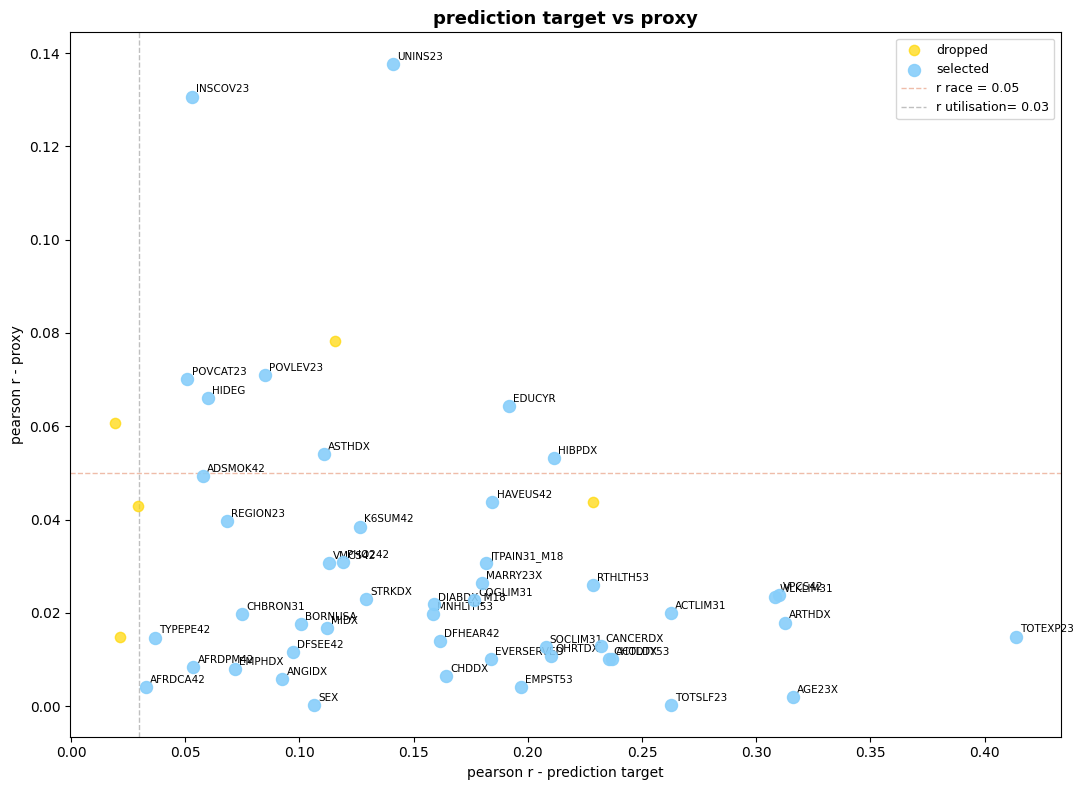

In [100]:
"""utilisation strenght <=> race
    target prediction with proxy
"""

fig, ax = plt.subplots(figsize=(11, 8))
kept = summary.index.isin(FINAL_FEATURES)
ax.scatter(summary.loc[~kept, "target"], summary.loc[~kept, "race"],
           color="gold", s=55, alpha=0.7, label="dropped", zorder=3)
ax.scatter(summary.loc[kept, "target"],  summary.loc[kept, "race"],
           color="lightskyblue", s=75, alpha=0.9, label="selected", zorder=4)
for col in FINAL_FEATURES:
    row = summary.loc[col]
    ax.annotate(col, (row["target"], row["race"]),
                fontsize=7.5, xytext=(3, 3), textcoords="offset points")
ax.axhline(0.05, color="#e07b54", lw=1, ls="--", alpha=0.5, label="r race = 0.05")
ax.axvline(0.03, color="gray", lw=1, ls="--", alpha=0.5, label="r utilisation= 0.03")
ax.set_xlabel("pearson r - prediction target")
ax.set_ylabel("pearson r - proxy")
ax.set_title("prediction target vs proxy", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/target_vs_proxy.png", dpi=150, bbox_inches="tight")
plt.show()

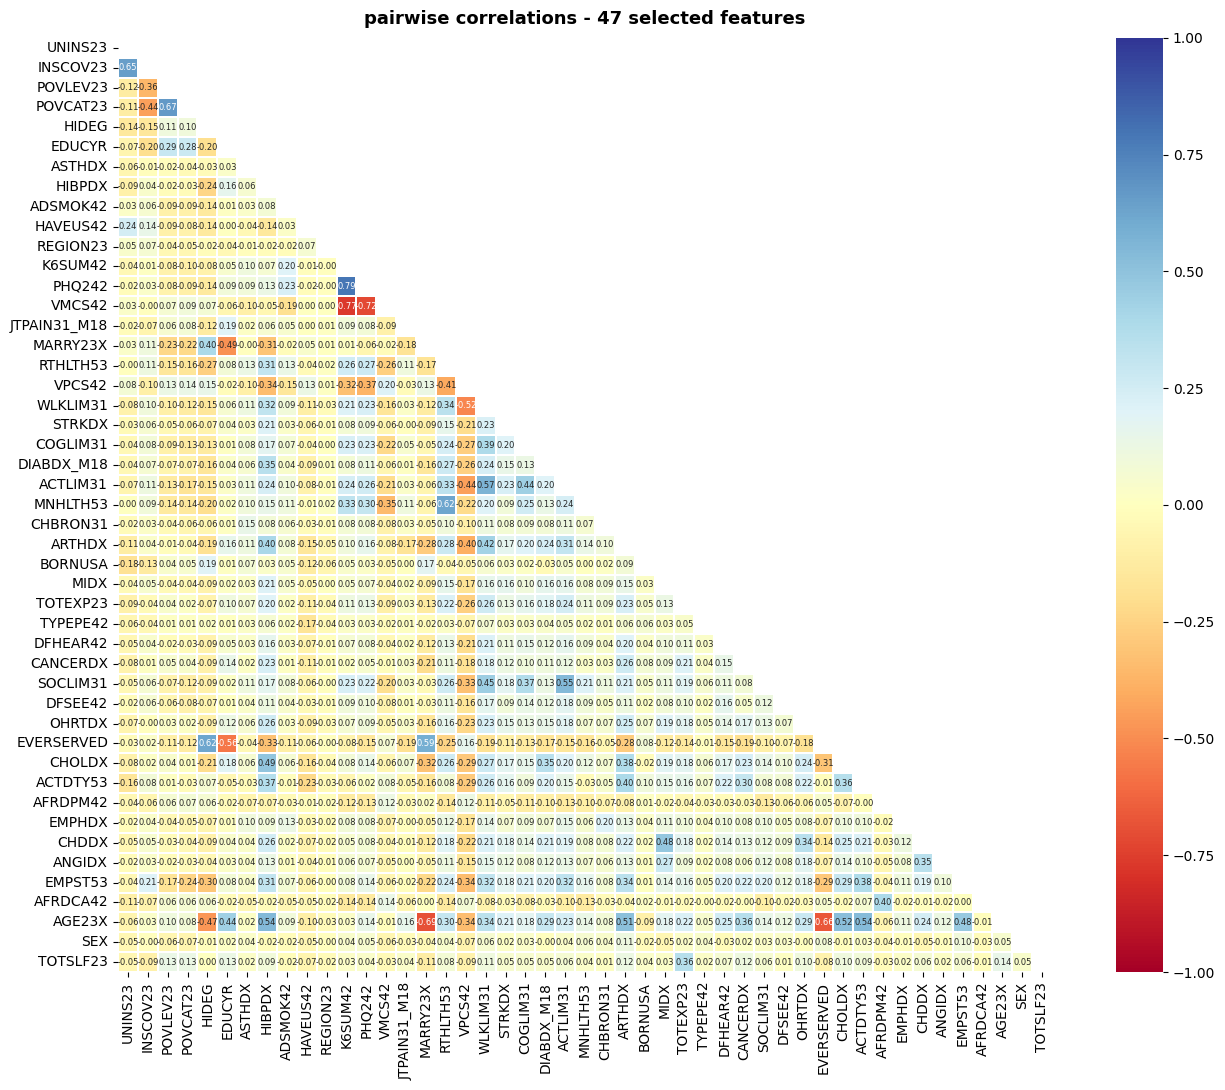


feature pairs with r > 0.60 (redundancy):
  K6SUM42                PHQ242                  r => 0.789
  K6SUM42                VMCS42                  r => 0.769
  PHQ242                 VMCS42                  r => 0.716
  MARRY23X               AGE23X                  r => 0.689
  POVLEV23               POVCAT23                r => 0.672
  EVERSERVED             AGE23X                  r => 0.665
  UNINS23                INSCOV23                r => 0.651
  HIDEG                  EVERSERVED              r => 0.619
  RTHLTH53               MNHLTH53                r => 0.617


In [101]:
"""feature correlation"""

corr = h251[FINAL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlBu", center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={"size": 6},
            ax=ax, square=True)
ax.set_title(f"pairwise correlations - {len(FINAL_FEATURES)} selected features", pad=10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nfeature pairs with r > 0.60 (redundancy):")
pairs = [
    (c1, c2, abs(corr.loc[c1, c2]))
    for i, c1 in enumerate(FINAL_FEATURES)
    for c2 in FINAL_FEATURES[i+1:]
    if abs(corr.loc[c1, c2]) > 0.60
]
if pairs:
    for c1, c2, r in sorted(pairs, key=lambda x: -x[2]):
        print(f"  {c1:<22} {c2:<22}  r => {r:.3f}")
else:
    print("no pairs exceed 0.60")

In [102]:
"""racial equity"""

RACE_LABELS = {1: "Hispanic", 2: "NH White", 3: "NH Black", 4: "NH Asian", 5: "NH Other"}

h251["race_label"] = h251["RACETHX"].map(RACE_LABELS)

rate_nh_white = h251[h251["RACETHX"] == 2]["UTILISATION"].mean()

# di_ratio => disparate impact
# spd => statistical parity diff
race_summary = (
    h251.groupby("race_label")
    .agg(n=("UTILISATION","count"), util_rate=("UTILISATION","mean"),
         mean_raw=("UTILISATION_RAW","mean"), uninsured=("UNINS23","mean"))
    .assign(di_ratio=lambda d: d["util_rate"]/rate_nh_white,
            spd=lambda d: d["util_rate"]-rate_nh_white)
    .round(3)
)

print(f"racial equity summary\n:\n{race_summary.to_string()}")

racial equity summary
:
                n  util_rate  mean_raw  uninsured  di_ratio    spd
race_label                                                        
Hispanic     4087      0.145     9.095      0.169     0.391 -0.226
NH Asian     1133      0.164     8.988      0.026     0.443 -0.207
NH Black     2448      0.205    11.887      0.054     0.554 -0.165
NH Other      683      0.242    11.813      0.038     0.652 -0.129
NH White    10112      0.371    14.572      0.032     1.000  0.000


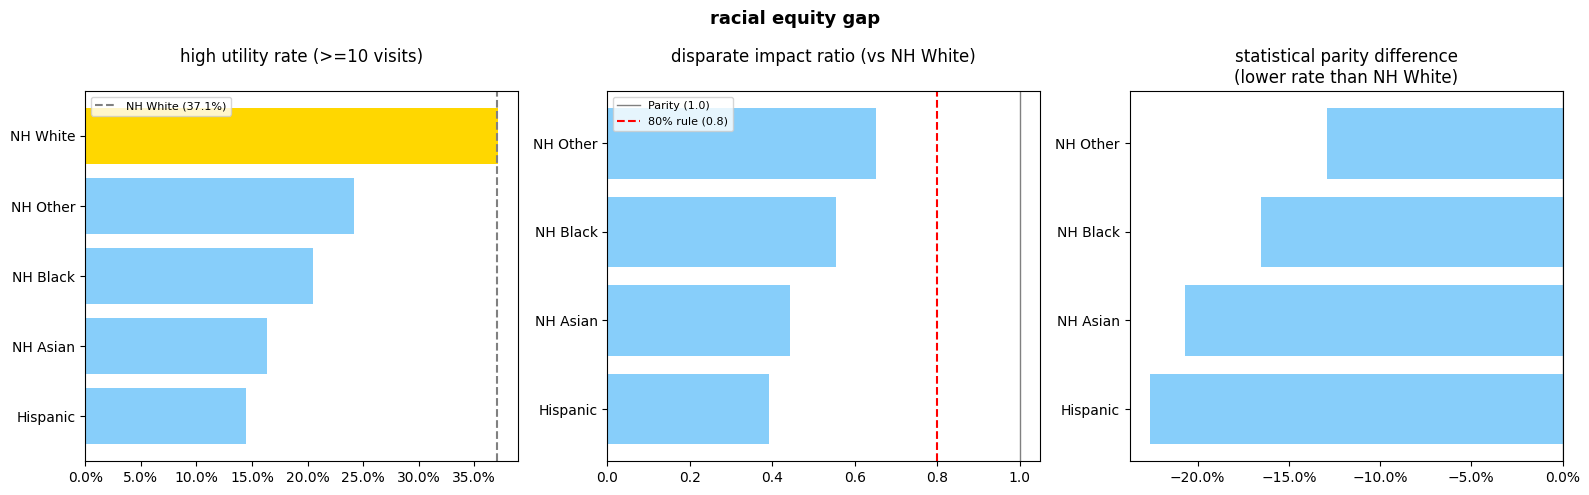

In [103]:
"""racial equity plot"""
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("racial equity gap", fontsize=13, fontweight="bold")
rs = race_summary.sort_values("util_rate")
axes[0].barh(rs.index, rs["util_rate"],
             color=["lightskyblue" if v < rate_nh_white else "gold" for v in rs["util_rate"]])
axes[0].axvline(rate_nh_white, color="gray", lw=1.5, ls="--", label=f"NH White ({rate_nh_white:.1%})")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title("high utility rate (>=10 visits)\n")
axes[0].legend(fontsize=8)
 
rs2 = race_summary[race_summary.index != "NH White"].sort_values("di_ratio")
axes[1].barh(rs2.index, rs2["di_ratio"],
             color=["lightskyblue" if v < 0.8 else "gold" for v in rs2["di_ratio"]])
axes[1].axvline(1.0, color="gray", lw=1, label="Parity (1.0)")
axes[1].axvline(0.8, color="red",  lw=1.5, ls="--", label="80% rule (0.8)")
axes[1].set_title("disparate impact ratio (vs NH White)\n")
axes[1].legend(fontsize=8)
 
rs3 = race_summary[race_summary.index != "NH White"].sort_values("spd")
axes[2].barh(rs3.index, rs3["spd"],
             color=["lightskyblue" if v < 0 else "gold" for v in rs3["spd"]])
axes[2].axvline(0, color="gray", lw=1)
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].set_title("statistical parity difference\n(lower rate than NH White)")
plt.tight_layout()
plt.savefig("../images/racial_equity.png", dpi=150, bbox_inches="tight")
plt.show()

variance per component:
  PC1: 15.0% cumulative: 15.0%
  PC2: 7.3% cumulative: 22.4%
  PC3: 5.4% cumulative: 27.8%
  PC4: 5.2% cumulative: 33.0%
  PC5: 3.3% cumulative: 36.3%
  PC6: 3.1% cumulative: 39.4%
  PC7: 2.8% cumulative: 42.1%
  PC8: 2.7% cumulative: 44.8%
  PC9: 2.6% cumulative: 47.4%
  PC10: 2.5% cumulative: 49.9%


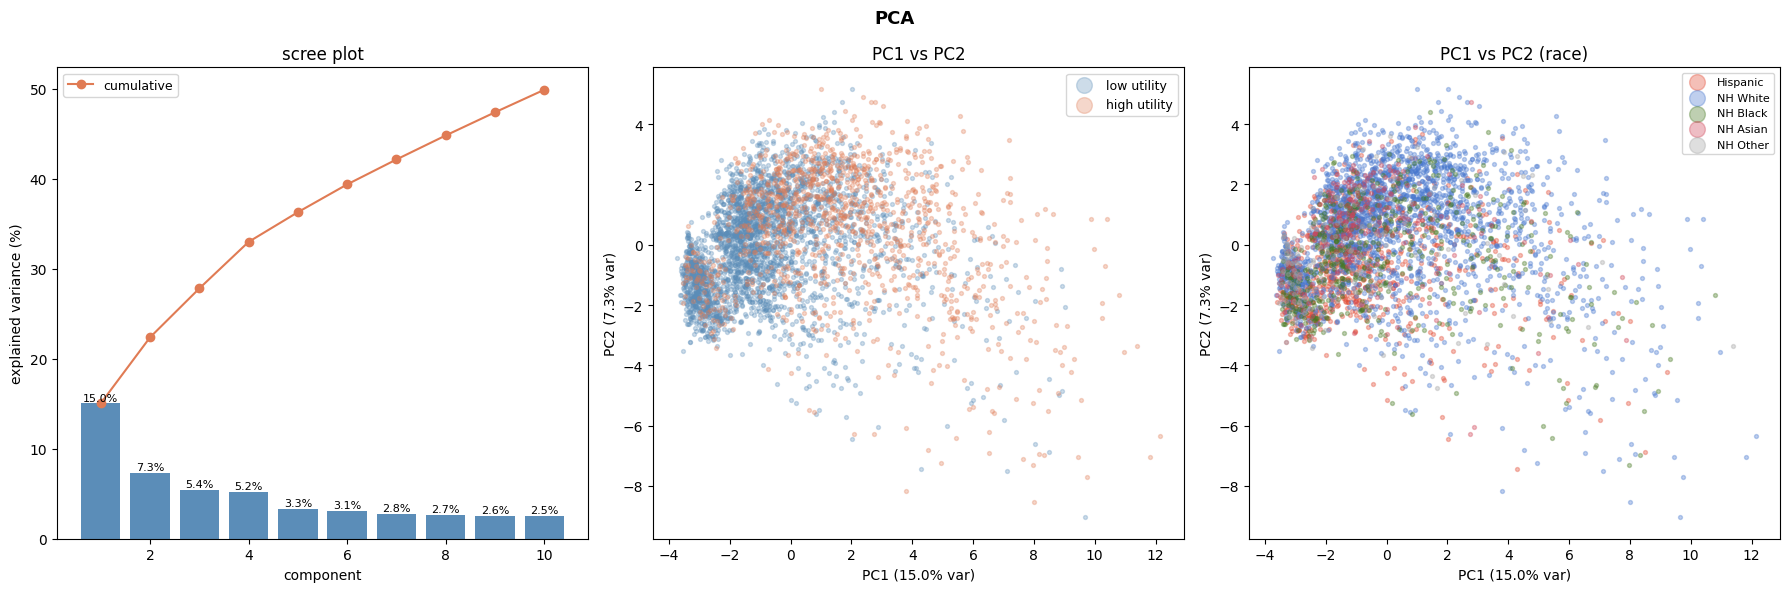

In [ ]:
"""PCA"""
scaler = StandardScaler()
X_scaled = scaler.fit_transform(h251[FINAL_FEATURES])
 
pca = PCA(n_components=10, random_state=42)
components = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
 
print("variance per component:")
for i, v in enumerate(evr):
    print(f"  PC{i+1}: {v:.1%} cumulative: {evr[:i+1].sum():.1%}")
 
rng = np.random.default_rng(42)
idx = rng.choice(len(components), size=min(4000, len(components)), replace=False)
pc1, pc2 = components[idx, 0], components[idx, 1]
util_sample = h251["UTILISATION"].values[idx]
race_sample = h251["RACETHX"].values[idx]
 
RACE_COLOR = {1:"#E24A33", 2:"#4878CF", 3:"#467821", 4:"#CF4457", 5:"#A2A2A2"}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("PCA", fontsize=13, fontweight="bold")
 
axes[0].bar(range(1, len(evr)+1), evr*100, color="#5b8db8")
axes[0].plot(range(1, len(evr)+1), np.cumsum(evr)*100, "o-", color="#e07b54", label="cumulative")
for i, v in enumerate(evr*100):
    axes[0].text(i+1, v+0.3, f"{v:.1f}%", ha="center", fontsize=8)
axes[0].set_xlabel("component")
axes[0].set_ylabel("explained variance (%)")
axes[0].set_title("scree plot")
axes[0].legend(fontsize=9)
 
for label, color, name in [(0, "#5b8db8", "low utility"), (1, "#e07b54", "high utility")]:
    m = util_sample == label
    axes[1].scatter(pc1[m], pc2[m], c=color, alpha=0.3, s=8, label=name)
axes[1].set_xlabel(f"PC1 ({evr[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({evr[1]:.1%} var)")
axes[1].set_title("PC1 vs PC2", )
axes[1].legend(markerscale=4, fontsize=9)
 
for rv, rl in RACE_LABELS.items():
    m = race_sample == rv
    if m.sum() > 0:
        axes[2].scatter(pc1[m], pc2[m], c=RACE_COLOR[rv], alpha=0.35, s=8, label=rl)
axes[2].set_xlabel(f"PC1 ({evr[0]:.1%} var)")
axes[2].set_ylabel(f"PC2 ({evr[1]:.1%} var)")
axes[2].set_title("PC1 vs PC2 (race)")
axes[2].legend(markerscale=4, fontsize=8)
 
plt.tight_layout()
plt.savefig("../images/pca.png", dpi=150, bbox_inches="tight")
plt.show()